In [4]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [5]:
# =========================
# Load dataset splits
# =========================
DATA_PATH = "../../Datasets/TCGA InfiniumPurify Dataset Splits"

X_train = pd.read_csv(f"{DATA_PATH}/X_train.csv")
X_test  = pd.read_csv(f"{DATA_PATH}/X_test.csv")
Y_train = pd.read_csv(f"{DATA_PATH}/Y_train.csv")
Y_test  = pd.read_csv(f"{DATA_PATH}/Y_test.csv")

# Ensure y is 1D
y_train = np.ravel(Y_train)
y_test  = np.ravel(Y_test)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((494, 19277), (123, 19277), (494,), (123,))


Calculating SHAP values...
SHAP values shape: (123, 100, 5)
Selected features: 100

=== Overall Top 10 Features ===
      Feature  MeanAbsSHAP_MaxAcrossSubtypes
82     SEPT12                       0.023437
2      AXDND1                       0.020362
31  TNFRSF10A                       0.019793
9     PA2G4P4                       0.018728
35      LRRC6                       0.017601
51   ARHGEF25                       0.017018
99     DOPEY2                       0.016626
59        CIT                       0.016582
81  LOC440335                       0.013333
79     ABCC11                       0.012994


C:\Users\Roooiz\AppData\Local\Temp\ipykernel_1840\4153067463.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


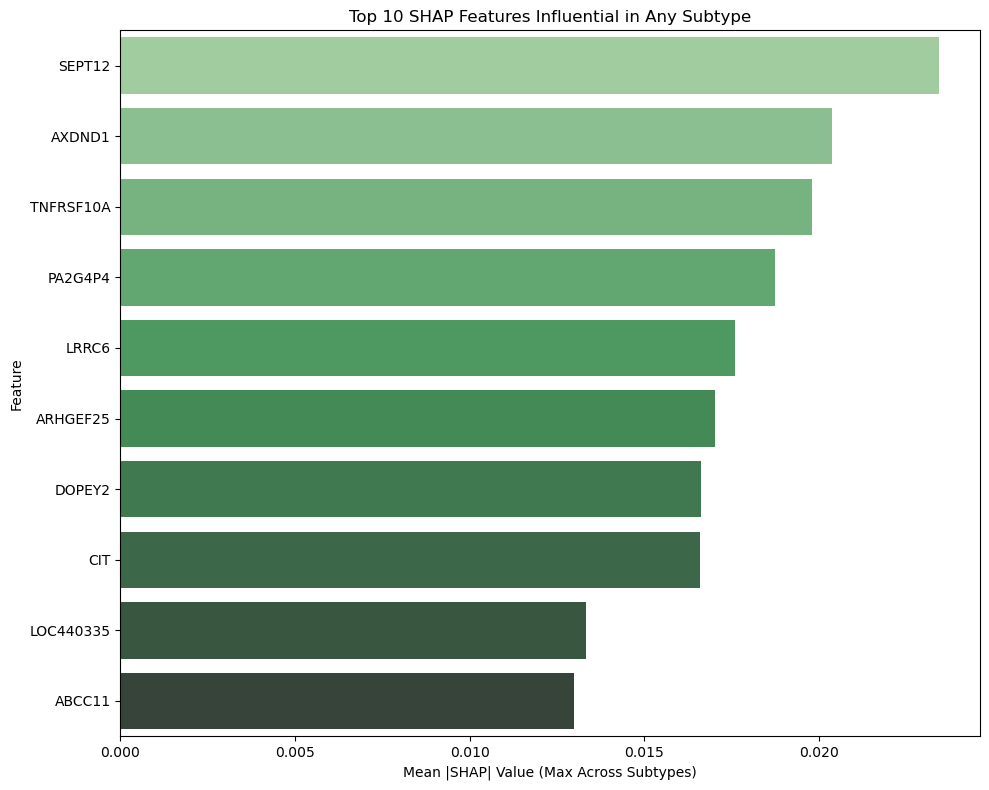

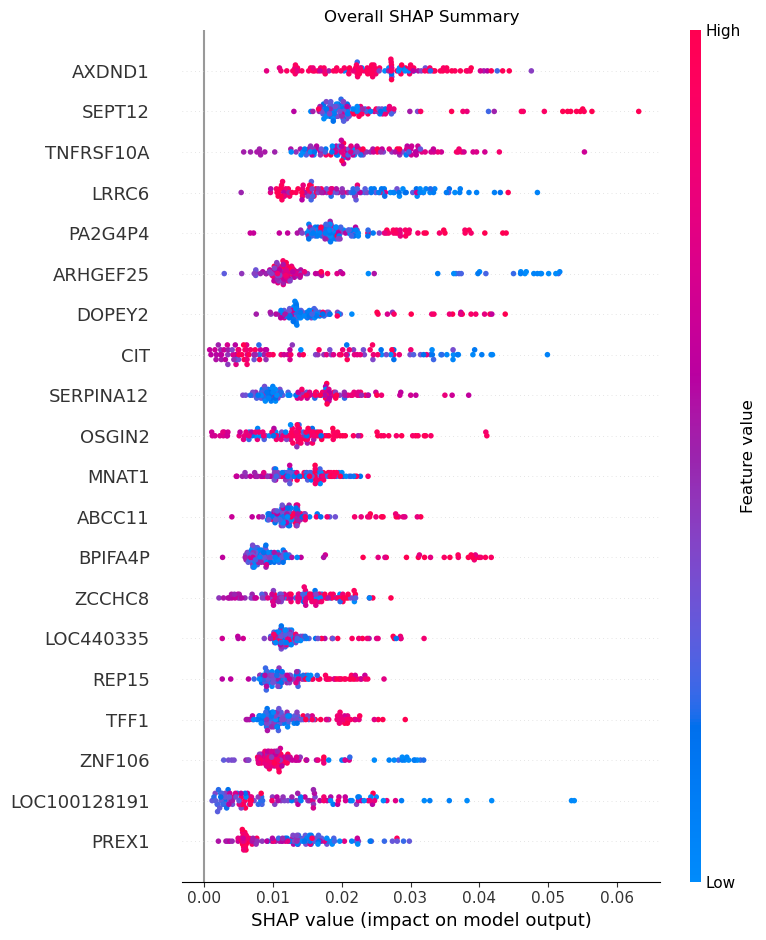


Subtype 1: Basal
      Feature  MeanAbsSHAP
82     SEPT12     0.023437
9     PA2G4P4     0.018728
99     DOPEY2     0.016626
2      AXDND1     0.014681
81  LOC440335     0.013333
79     ABCC11     0.012994
1     MIR135B     0.011780
98       TFF1     0.010312
32   MIR124-2     0.009782
61      REP15     0.008439


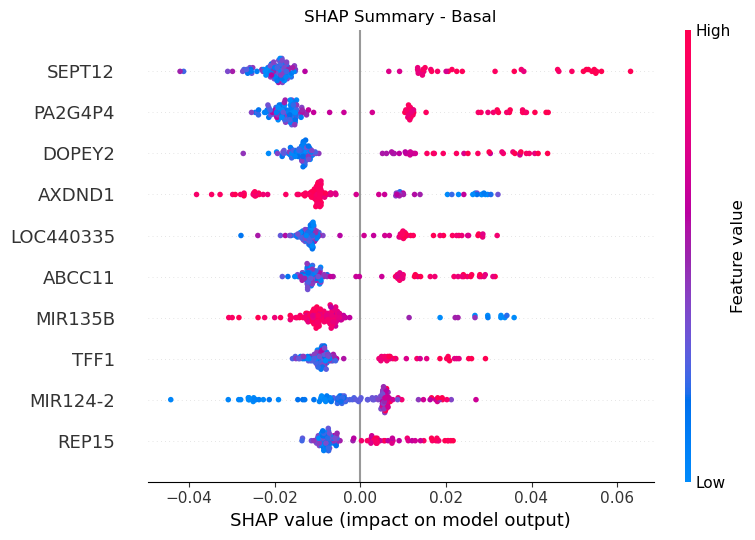

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_1840\4153067463.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


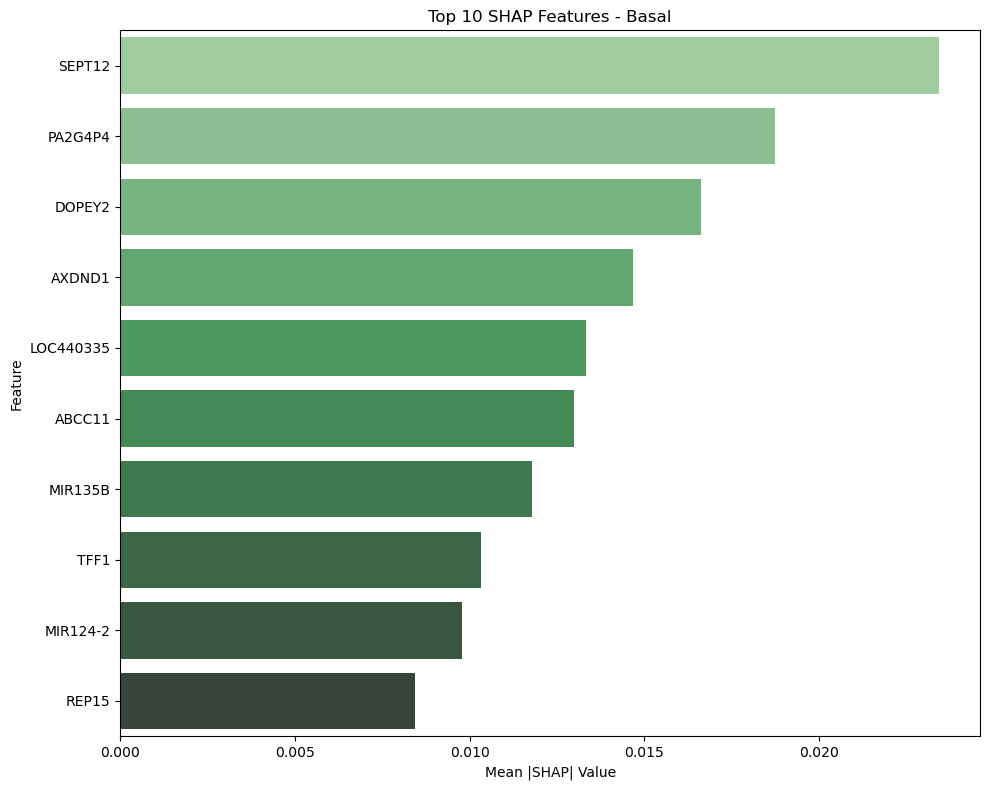


Subtype 2: Her2
      Feature  MeanAbsSHAP
2      AXDND1     0.017957
35      LRRC6     0.017480
31  TNFRSF10A     0.016435
69  SERPINA12     0.012502
95      PREX1     0.011733
30     OSGIN2     0.011499
24       LSM2     0.011438
9     PA2G4P4     0.011308
99     DOPEY2     0.011197
82     SEPT12     0.010110


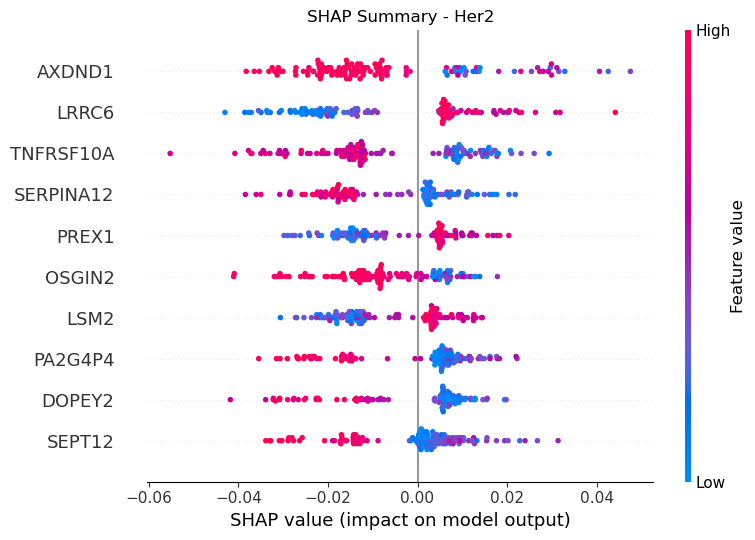

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_1840\4153067463.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


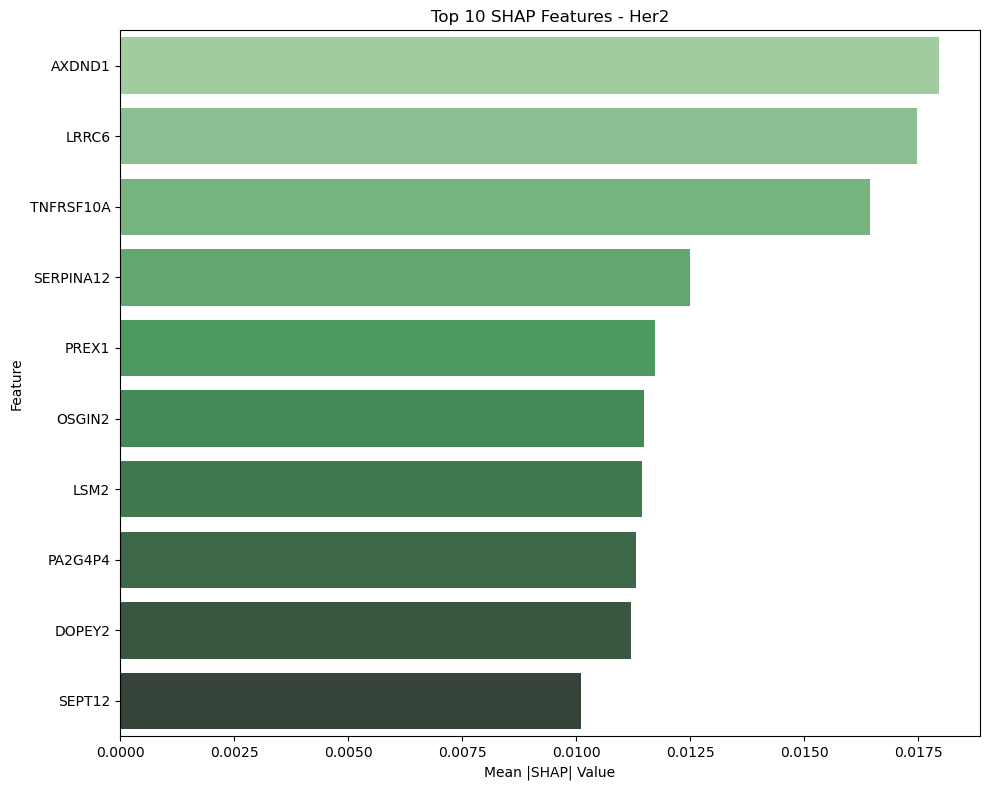


Subtype 3: LumA
         Feature  MeanAbsSHAP
2         AXDND1     0.020362
31     TNFRSF10A     0.019793
59           CIT     0.016582
82        SEPT12     0.014043
30        OSGIN2     0.012959
58       MIR1178     0.012300
53  LOC100128191     0.012254
69     SERPINA12     0.011306
50        ZCCHC8     0.010912
95         PREX1     0.010886


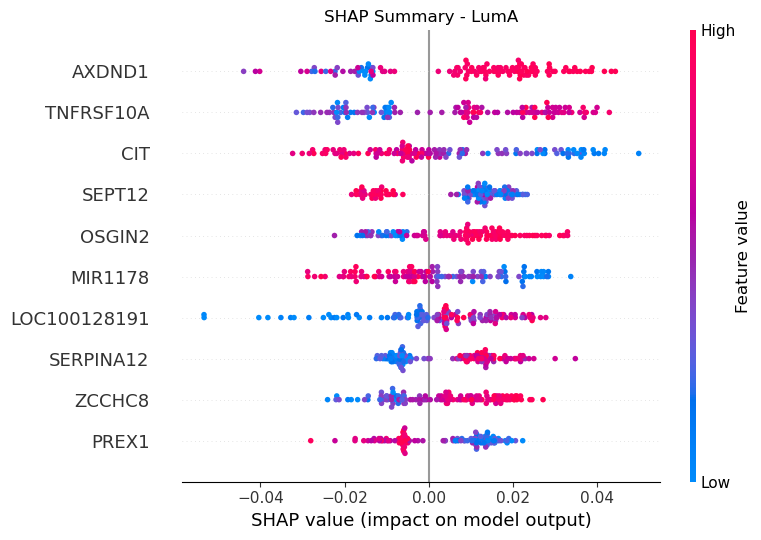

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_1840\4153067463.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


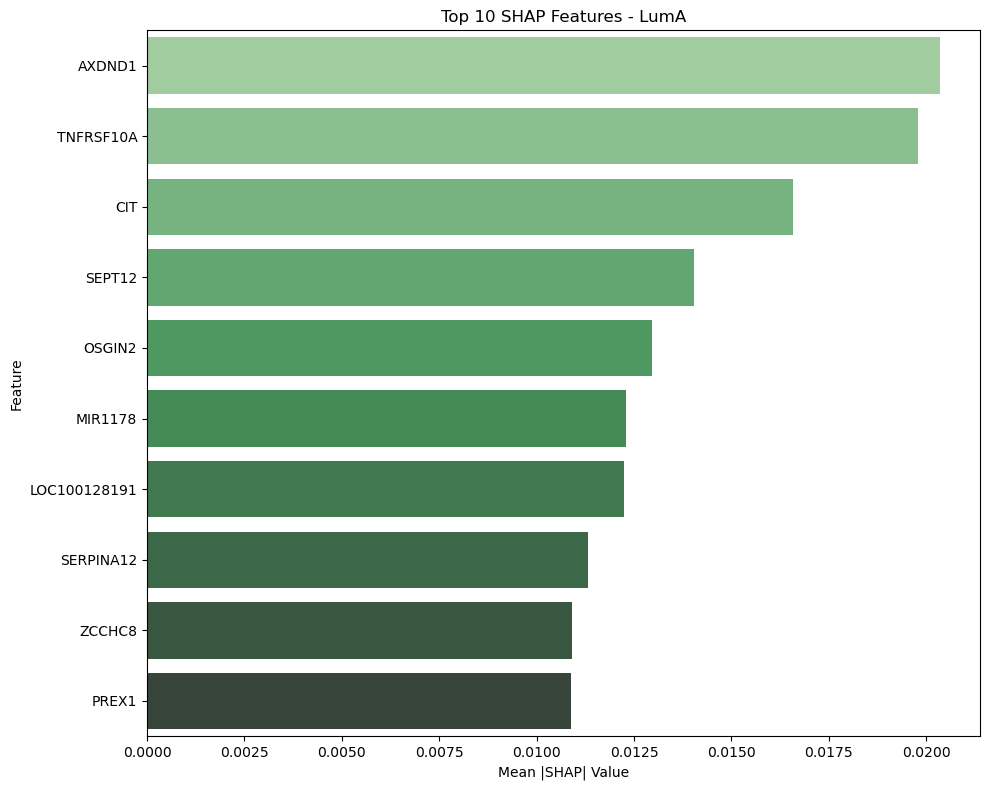


Subtype 4: LumB
         Feature  MeanAbsSHAP
35         LRRC6     0.017601
59           CIT     0.012007
53  LOC100128191     0.011835
69     SERPINA12     0.011689
9        PA2G4P4     0.010827
58       MIR1178     0.010687
8       ERC2-IT1     0.010512
54          TMPO     0.010408
82        SEPT12     0.010186
71         MNAT1     0.009909


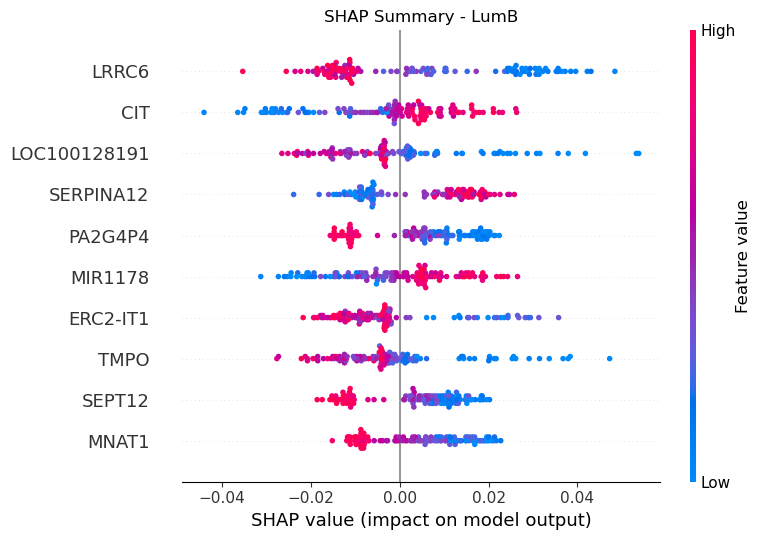

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_1840\4153067463.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


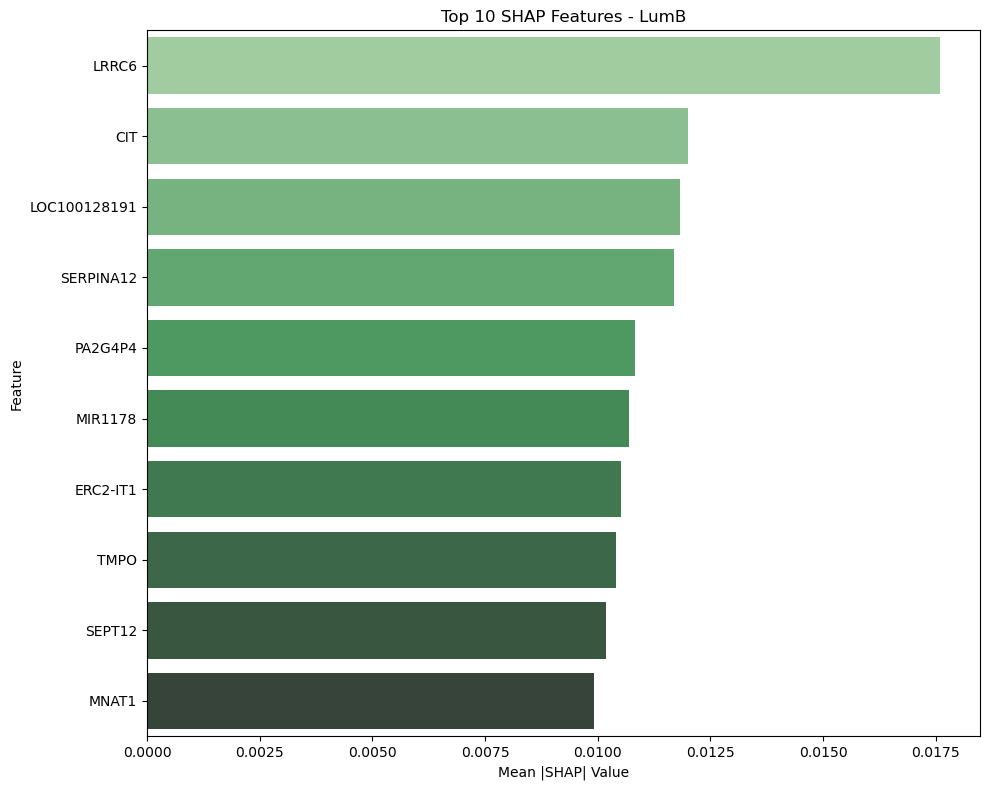


Subtype 5: Normal
      Feature  MeanAbsSHAP
51   ARHGEF25     0.017018
9     PA2G4P4     0.013459
92    BPIFA4P     0.012471
75     ZNF106     0.012157
82     SEPT12     0.010961
60   TMEM132B     0.010103
31  TNFRSF10A     0.010000
61      REP15     0.009979
64       SOX1     0.009105
13    FAM193A     0.008907


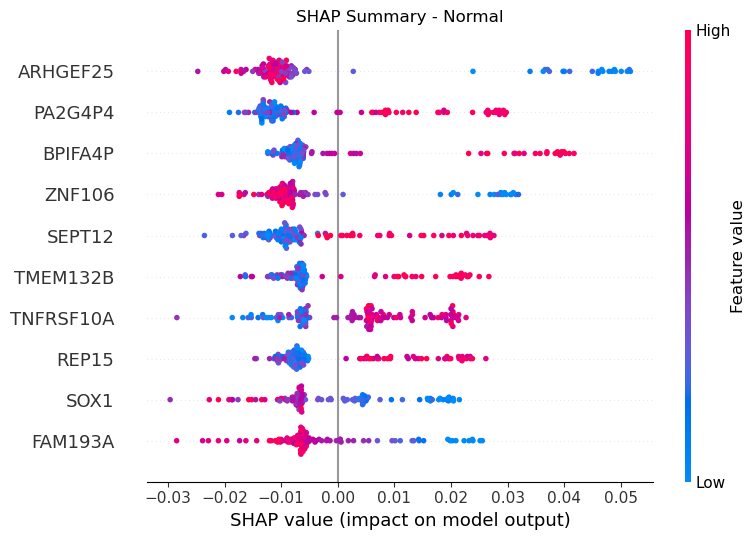

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_1840\4153067463.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


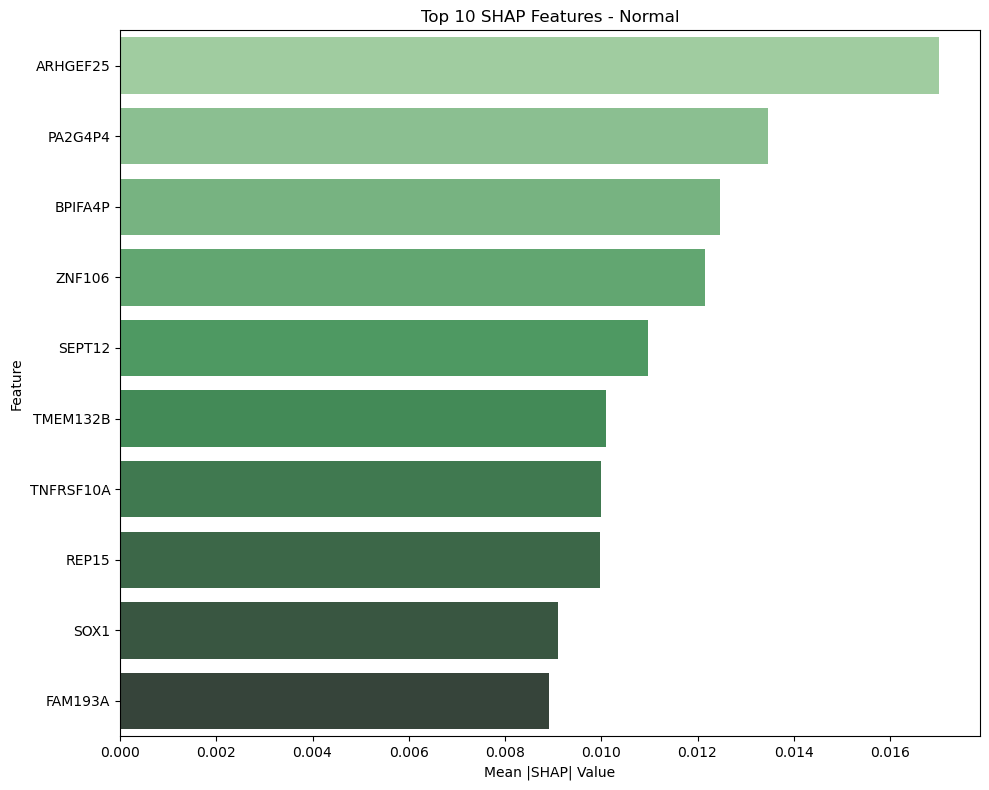


SHAP analysis complete — both overall and per-subtype results generated.


In [6]:
# --- Choose your model ---
best_model_rfe = joblib.load("PKL/RF_TCGA_IP_SMOTE_RFE.pkl")
pipeline_model = best_model_rfe  # or best_model_no_rfe

# --- Extract components ---
rfe = pipeline_model.named_steps['rfe']
rf_model = pipeline_model.named_steps['rf']
scaler = pipeline_model.named_steps['scaler']

# --- Prepare data ---
selected_mask = rfe.support_  # which features RFE kept
selected_features = np.array(X_test.columns)[selected_mask]

# Scale test set
X_test_scaled = scaler.transform(X_test)
X_test_selected = X_test_scaled[:, selected_mask]

# --- Create SHAP explainer ---
print("\nCalculating SHAP values...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_selected)

# Handle multi-class output
if isinstance(shap_values, list):  # one array per class
    shap_values = np.stack(shap_values, axis=2)  # shape: (samples, features, classes)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Selected features: {len(selected_features)}")

# ====================================================
# 1. OVERALL (across all classes)
# ====================================================
mean_abs_shap_anywhere = np.abs(shap_values).mean(axis=0).max(axis=1)

shap_importances_overall = pd.DataFrame({
    "Feature": selected_features,
    "MeanAbsSHAP_MaxAcrossSubtypes": mean_abs_shap_anywhere
}).sort_values(by="MeanAbsSHAP_MaxAcrossSubtypes", ascending=False)

print("\n=== Overall Top 10 Features ===")
print(shap_importances_overall.head(10))

# Bar plot
plt.figure(figsize=(10, 8))
sns.barplot(
    data=shap_importances_overall.head(10),
    x="MeanAbsSHAP_MaxAcrossSubtypes",
    y="Feature",
    palette="Greens_d"
)
plt.title("Top 10 SHAP Features Influential in Any Subtype")
plt.xlabel("Mean |SHAP| Value (Max Across Subtypes)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Overall SHAP summary
shap_values_overall = np.abs(shap_values).max(axis=2)  # max per sample across classes
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_overall, X_test_selected,
    feature_names=selected_features,
    max_display=20, show=False
)
plt.title("Overall SHAP Summary")
plt.tight_layout()
plt.show()

# ====================================================
# 2. PER-CLASS (each subtype separately)
# ====================================================
class_names = rf_model.classes_
for class_idx, class_name in enumerate(class_names):
    print(f"\n{'='*50}")
    print(f"Subtype {class_idx + 1}: {class_name}")
    
    shap_values_class = shap_values[:, :, class_idx]
    class_mean_abs_shap = np.abs(shap_values_class).mean(axis=0)
    
    shap_importances_class = pd.DataFrame({
        "Feature": selected_features,
        "MeanAbsSHAP": class_mean_abs_shap
    }).sort_values(by="MeanAbsSHAP", ascending=False)
    
    print(shap_importances_class.head(10))
    
    # SHAP summary plot per class
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values_class, X_test_selected,
        feature_names=selected_features,
        max_display=10, show=False
    )
    plt.title(f"SHAP Summary - {class_name}")
    plt.tight_layout()
    plt.show()
    
    # Bar plot top 10 per class
    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=shap_importances_class.head(10),
        x="MeanAbsSHAP",
        y="Feature",
        palette="Greens_d"
    )
    plt.title(f"Top 10 SHAP Features - {class_name}")
    plt.xlabel("Mean |SHAP| Value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

print("\nSHAP analysis complete — both overall and per-subtype results generated.")